# Занятие 1. Семинар: kNN и наивный Байес

Сегодня две задачи. Первая — убедиться, что у всех работает окружение.
Вторая — своими руками написать два первых алгоритма машинного обучения
и посмотреть, как те же самые вещи выглядят в библиотеке.

Ничего не скачиваем из интернета: все данные приезжают вместе с scikit-learn.

**Как работать с ноутбуком.** Ячейки идут по порядку, запускать сверху вниз.
Там, где написано `# TODO: ваш код`, мы пишем код вместе на паре.
Сразу за каждой такой ячейкой идет ячейка с проверками: если она отработала
без ошибок и напечатала, что все в порядке, можно идти дальше.
Решенная версия появится в репозитории вечером.

## 0. Окружение

Проверяем, что все встало. Если какая-то строчка ругается, зовите меня.

In [1]:
import sys
import platform

print("python", platform.python_version())

for name in ["numpy", "pandas", "matplotlib", "sklearn"]:
    try:
        module = __import__(name)
        print(f"  ok       {name} {getattr(module, '__version__', '?')}")
    except ImportError:
        print(f"  MISSING  {name}")

python 3.11.16
  ok       numpy 2.4.6
  ok       pandas 3.0.5
  ok       matplotlib 3.11.1
  ok       sklearn 1.9.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
rng = np.random.default_rng(SEED)

## 1. Данные

Датасет про вино: химический анализ вин трех сортов, выращенных в одном
регионе Италии. По результатам анализа нужно определить сорт.

Он маленький и приезжает вместе с библиотекой, так что подходит,
чтобы разобраться в механике, не отвлекаясь на загрузку данных.

In [3]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
data = wine.frame

print("объектов:", data.shape[0])
print("колонок: ", data.shape[1])
data.head()

объектов: 178
колонок:  14


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Разберемся, что здесь что.

- `data` — таблица: строка это один объект, колонка это один признак;
- `target` — то, что мы предсказываем, номер сорта;
- остальные тринадцать колонок — то, из чего предсказываем

Слова, которые дальше будут повторяться весь семестр: **объект**, **признак**,
**целевая переменная**. Объект это строка, признак это колонка, целевая
переменная это отдельная колонка, ради которой все затевается.

In [4]:
print("названия признаков:")
for i, name in enumerate(wine.feature_names):
    print(f"  {i:2d}  {name}")

print()
print("классы:", dict(zip(range(3), wine.target_names)))
print()
print(data["target"].value_counts().sort_index())

названия признаков:
   0  alcohol
   1  malic_acid
   2  ash
   3  alcalinity_of_ash
   4  magnesium
   5  total_phenols
   6  flavanoids
   7  nonflavanoid_phenols
   8  proanthocyanins
   9  color_intensity
  10  hue
  11  od280/od315_of_diluted_wines
  12  proline

классы: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}

target
0    59
1    71
2    48
Name: count, dtype: int64


### Первое, на что всегда стоит посмотреть

Не на модель, а на масштаб признаков. Запомните этот вывод, через
двадцать минут он нам пригодится.

In [5]:
summary = data.drop(columns="target").describe().T[["mean", "std", "min", "max"]]
summary.sort_values("max", ascending=False).head(6)

,mean,std,min,max
proline,746.893258,314.907474,278.00,1680.00
magnesium,99.741573,14.282484,70.00,162.00
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
alcohol,13.000618,0.811827,11.03,14.83
color_intensity,5.058090,2.318286,1.28,13.00
malic_acid,2.336348,1.117146,0.74,5.80


Разброс колоссальный. У `proline` значения около тысячи, у `nonflavanoid_phenols` —
десятые доли. Разница в четыре порядка. Пока просто отметим это.

## 2. Постановка задачи

Формально задача обучения с учителем выглядит так.

Есть таблица признаков $X$ размера $n \times d$: $n$ объектов, $d$ признаков.
Есть вектор ответов $y$ длины $n$.

Нужно построить **решающее правило** — функцию, которая по объекту
выдает ответ:

$$a: \mathcal{X} \rightarrow \mathcal{Y}$$

Здесь $\mathcal{X}$ — множество всех возможных объектов, $\mathcal{Y}$ —
множество допустимых ответов. Для наших вин объект это набор из тринадцати
чисел, а ответ это один из трех сортов, то есть $\mathcal{Y} = \{0, 1, 2\}$.

Обозначение $a(x)$ будет встречаться до конца курса. Подали объект $x$ —
получили ответ $a(x)$. Все методы, которые мы пройдем, отличаются только
тем, **как именно устроена** эта функция и **как ее подбирают**
по обучающей выборке.

Задача обучения — найти такую $a$, которая хорошо отвечает не на тех
объектах, что мы уже видели, а на новых.

Слово «учитель» означает ровно одно: нам заранее показали правильные ответы
на части данных. Все остальное в машинном обучении — вариации на эту тему.

In [6]:
X = data.drop(columns="target").to_numpy()
y = data["target"].to_numpy()

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

X: (178, 13) float64
y: (178,) int64


## 3. Как честно измерить качество

Соблазн такой: обучить модель на всех данных, на них же проверить, получить
высокий результат и обрадоваться. Так делать нельзя, и вот почему.

Представьте модель, которая просто запомнила всю таблицу. На знакомых объектах
она отвечает идеально, на новых — как повезет. Проверка на тех же данных,
на которых учились, измеряет память, а не умение обобщать.

Поэтому данные делятся заранее. Одна часть для обучения, вторая откладывается
и не трогается до самого конца.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y,      # сохранить доли классов в обеих частях
)

print("train:", X_train.shape[0], "объектов")
print("test: ", X_test.shape[0], "объектов")
print()
print("доли классов в train:", np.round(np.bincount(y_train) / len(y_train), 3))
print("доли классов в test: ", np.round(np.bincount(y_test) / len(y_test), 3))

train: 124 объектов
test:  54 объектов

доли классов в train: [0.331 0.403 0.266]
доли классов в test:  [0.333 0.389 0.278]


Параметр `stratify=y` следит, чтобы доли классов в обеих частях совпадали.
Без него на маленькой выборке легко получить перекос, и тогда результат
на тесте будет говорить больше о неудачном делении, чем о модели.

## 4. Baseline и знакомство с scikit-learn

Прежде чем строить модель, надо понять, с чем сравнивать. Простейшая
стратегия: всегда отвечать самым частым классом. Она ничего не знает
о признаках, и любая осмысленная модель обязана ее обыграть.

Заодно разберем на ней, как вообще устроена библиотека, в которой мы
проведем весь семестр.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# 1. создаем модель: пока это просто объект с настройками, он ничего не знает
dummy = DummyClassifier(strategy="most_frequent")
print("до обучения:", dummy)

# 2. обучаем: модель смотрит на данные и запоминает то, что ей нужно
dummy.fit(X_train, y_train)

# 3. предсказываем: применяем выученное к новым объектам
y_pred_dummy = dummy.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_dummy)
print("baseline accuracy:", round(baseline_acc, 3))

до обучения: DummyClassifier(strategy='most_frequent')
baseline accuracy: 0.389


### Три строчки, которые повторятся сто раз

Разберем их по отдельности, потому что дальше весь курс устроен так же.

**Создание объекта.** `DummyClassifier(strategy="most_frequent")` — это еще
не модель, это только настройки. Такие настройки называют
**гиперпараметрами**: их выбирает человек, а не данные. У kNN это будет
число соседей, у дерева — глубина.

**`fit(X, y)` — обучение.** Модель получает объекты и правильные ответы
и настраивает себя под них. Что именно она при этом запоминает, зависит
от метода: наша заглушка запомнит самый частый класс, наивный Байес —
средние и дисперсии, kNN — вообще всю выборку целиком.

**`predict(X)` — применение.** Модель получает только объекты, без ответов,
и выдает свои. Здесь она уже ничему не учится.

Разница между `fit` и `predict` — это разница между «настроиться по данным»
и «применить настроенное». Путать их нельзя, и главное правило курса
следует прямо отсюда: **`fit` вызывается только на обучающей выборке**.
Если вызвать его на тесте, модель подсмотрит ответы, и проверка перестанет
что-либо значить.

In [9]:
# все, что модель выучила, она складывает в атрибуты с подчеркиванием на конце
print("классы, которые видела модель:", dummy.classes_)
print("класс, которым она всегда отвечает:", dummy.classes_[dummy.predict(X_test[:1])[0]])
print()

# predict можно звать сколько угодно раз, модель от этого не меняется
print("первые десять предсказаний:", dummy.predict(X_test[:10]))
print("и они не меняются:      ", dummy.predict(X_test[:10]))

классы, которые видела модель: [0 1 2]
класс, которым она всегда отвечает: 1

первые десять предсказаний: [1 1 1 1 1 1 1 1 1 1]
и они не меняются:       [1 1 1 1 1 1 1 1 1 1]


Подчеркивание на конце имени — соглашение библиотеки: так помечают все,
что появилось в результате `fit`. Если атрибут без подчеркивания, значит
его задали вы при создании объекта.

Проверить это соглашение просто: у необученной модели таких атрибутов нет,
и обращение к ним падает с понятной ошибкой.

In [10]:
fresh = DummyClassifier(strategy="most_frequent")
try:
    fresh.predict(X_test)
except Exception as error:
    print(type(error).__name__)
    print(str(error)[:160])

NotFittedError
This DummyClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


Так выглядит попытка применить модель, которую забыли обучить. Ошибку
`NotFittedError` вы еще увидите не раз, и теперь знаете, что она означает
ровно одно: между созданием объекта и `predict` потерялся `fit`.

In [11]:
# --- проверка ---

# 1. accuracy это доля, она обязана лежать между нулем и единицей
assert 0.0 <= baseline_acc <= 1.0, "accuracy вне отрезка [0, 1]"

# 2. модель отвечает всегда одним и тем же классом
assert len(np.unique(y_pred_dummy)) == 1, "константная модель должна давать один класс"

# 3. и это самый частый класс обучающей выборки
most_frequent = np.bincount(y_train).argmax()
assert y_pred_dummy[0] == most_frequent, "предсказан не самый частый класс трейна"

# 4. значит accuracy равна доле этого класса в тесте
expected = (y_test == most_frequent).mean()
assert np.isclose(baseline_acc, expected), f"ожидали {expected:.3f}, получили {baseline_acc:.3f}"

print(f"проверки пройдены, baseline = {baseline_acc:.3f}")

проверки пройдены, baseline = 0.389


**Accuracy** — доля правильных ответов. Первая метрика курса, и самая
обманчивая: на несбалансированных данных она врет так, что на нее нельзя
смотреть вообще. К этому вернемся в конце семинара.

Запомните полученное число. Все, что мы построим дальше, сравнивается
именно с ним.

### Посмотрим на модель глазами

Числа это хорошо, но полезнее увидеть, **как** модель делит пространство.
Признаков у нас тринадцать, нарисовать столько нельзя, поэтому берем любые
два и смотрим на плоскости.

Функция ниже готова, разбирать ее построчно не нужно. Она делает три вещи:
обучает копию модели на двух выбранных признаках, закрашивает плоскость
в цвет предсказанного класса, а поверх раскладывает тестовые объекты.
Ошибки помечает крестиком.

Важная оговорка: модель на картинке обучена только на двух признаках,
поэтому качество у нее ниже, чем у настоящей на тринадцати. Картинка
показывает форму границы, а не итоговую точность.

In [12]:
from matplotlib.colors import ListedColormap
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

CLASS_CMAP = ListedColormap(["#0072CE", "#0F1418", "#C98A3C"])


def show_decision(model, feature_a="flavanoids", feature_b="color_intensity",
                  title="", scale=False, ax=None):
    """Нарисовать, как модель делит плоскость двух признаков.

    model     — необученная модель, копия обучится внутри
    feature_a — признак по горизонтальной оси
    feature_b — признак по вертикальной оси
    scale     — стандартизовать ли признаки перед обучением
    """
    i = wine.feature_names.index(feature_a)
    j = wine.feature_names.index(feature_b)
    train, test = X_train[:, [i, j]], X_test[:, [i, j]]

    if scale:
        local_scaler = StandardScaler()
        train = local_scaler.fit_transform(train)
        test = local_scaler.transform(test)

    fitted = clone(model).fit(train, y_train)
    predicted = fitted.predict(test)
    correct = predicted == y_test

    # рамка должна вмещать и обучающие объекты, и тестовые
    both = np.vstack([train, test])
    pad = (both.max(axis=0) - both.min(axis=0)) * 0.06
    x_min, y_min = both.min(axis=0) - pad
    x_max, y_max = both.max(axis=0) + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    zones = fitted.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 4.8))
    ax.contourf(xx, yy, zones, alpha=0.22, cmap=CLASS_CMAP,
                levels=[-0.5, 0.5, 1.5, 2.5])
    ax.scatter(train[:, 0], train[:, 1], c=y_train, cmap=CLASS_CMAP,
               s=26, alpha=0.45, edgecolor="none", label="обучающие")
    ax.scatter(test[correct, 0], test[correct, 1], c=y_test[correct],
               cmap=CLASS_CMAP, s=62, edgecolor="white", linewidth=1.1,
               label="тест, угадано")
    ax.scatter(test[~correct, 0], test[~correct, 1], marker="X", s=140,
               color="#E03A3A", edgecolor="white", linewidth=1.2,
               label=f"тест, ошибка ({(~correct).sum()})")

    ax.set_xlabel(feature_a)
    ax.set_ylabel(feature_b)
    ax.set_title(title or type(model).__name__)
    ax.grid(False)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
    return ax

Начнем с заглушки. Она отвечает всем одинаково, поэтому вся плоскость
должна оказаться одного цвета — модель просто не смотрит на признаки.

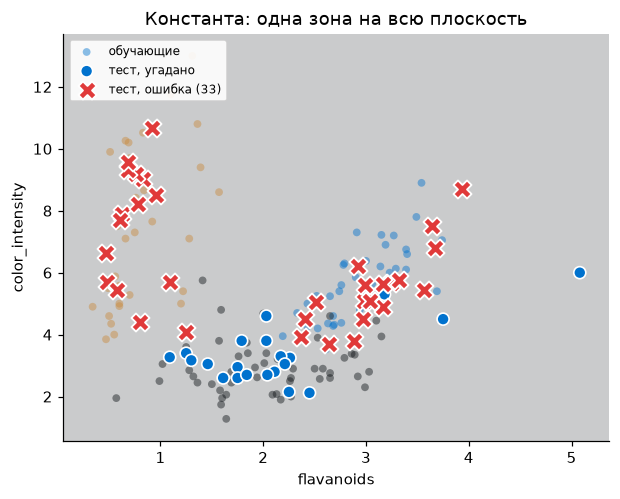

In [13]:
show_decision(DummyClassifier(strategy="most_frequent"),
              title="Константа: одна зона на всю плоскость")
plt.show()

Так и вышло. Крестиками помечены все объекты, которые модель не угадала,
а их тут большинство. Это выглядит глупо, и именно поэтому такая модель
годится только как точка отсчета.

## 5. Метод ближайших соседей

Идея помещается в одну фразу: **похожие объекты имеют похожие ответы**.

Алгоритм для нового объекта:

1. посчитать расстояние до всех объектов обучающей выборки
2. взять $k$ ближайших
3. вернуть класс, который среди них встретился чаще

Обучения здесь нет вообще. Модель просто хранит выборку, а вся работа
происходит в момент предсказания. Такие методы называют ленивыми.

В терминах второго раздела: решающее правило $a(x)$ здесь устроено как
голосование соседей. Формулы с настраиваемыми параметрами у него нет,
вся модель — это сама обучающая выборка.

### Что значит «ближайший»

Расстояние по умолчанию евклидово, то самое из школьной геометрии,
только в тринадцати измерениях вместо двух:

$$\rho(a, b) = \sqrt{\sum_{j=1}^{d} (a_j - b_j)^2}$$

Обратите внимание: сумма идет **по всем признакам**, и каждый вносит свой
вклад. Через двадцать минут из этой безобидной строчки вырастет главная
проблема метода.

Бывают и другие метрики — манхэттенская, косинусная. На лабораторной вы
напишете их сами и посмотрите, что изменится.

### Запускаем

Интерфейс тот же, что у заглушки: создать, `fit`, `predict`. Меняется
одна строчка — имя класса.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_knn)

print(f"kNN, k=5:  {acc_raw:.3f}")
print(f"baseline:  {baseline_acc:.3f}")

kNN, k=5:  0.722
baseline:  0.389


In [15]:
# --- проверка ---

# 1. на каждый объект теста ровно одно предсказание
assert y_pred_knn.shape == y_test.shape, "не совпало число предсказаний"

# 2. предсказаны только те классы, что были в обучающей выборке
assert set(np.unique(y_pred_knn)) <= set(np.unique(y_train)), "предсказан несуществующий класс"

# 3. модель действительно обучена: у нее появились атрибуты с подчеркиванием
assert hasattr(knn, "n_features_in_"), "похоже, fit не вызывался"
assert knn.n_features_in_ == X_train.shape[1], "модель ждет другое число признаков"

# 4. и она осмысленнее константного ответа
assert acc_raw > baseline_acc, "kNN не обыграл константный baseline"

print(f"проверки пройдены, accuracy = {acc_raw:.3f}")

проверки пройдены, accuracy = 0.722


### Что kNN хранит после fit

У большинства методов `fit` сжимает данные в несколько чисел. У kNN не так:
он запоминает выборку целиком, и легко в этом убедиться.

In [16]:
print("объектов запомнено:", knn._fit_X.shape[0])
print("признаков у каждого:", knn._fit_X.shape[1])
print("совпадает с обучающей выборкой:", np.array_equal(knn._fit_X, X_train))
print()
print("а вот у заглушки внутри всего одно число:", dummy.classes_)

объектов запомнено: 124
признаков у каждого: 13
совпадает с обучающей выборкой: True

а вот у заглушки внутри всего одно число: [0 1 2]


Отсюда два практических следствия. Первое: обучение kNN бесплатно, оно
сводится к копированию массива. Второе: предсказание дорогое, потому что
на каждый новый объект приходится пересчитывать расстояния до всех
запомненных. Чем больше выборка, тем медленнее модель отвечает — ровно
наоборот по сравнению с большинством методов.

### Как kNN делит плоскость

Теперь то же самое для настоящей модели. Разница с заглушкой должна быть
видна сразу.

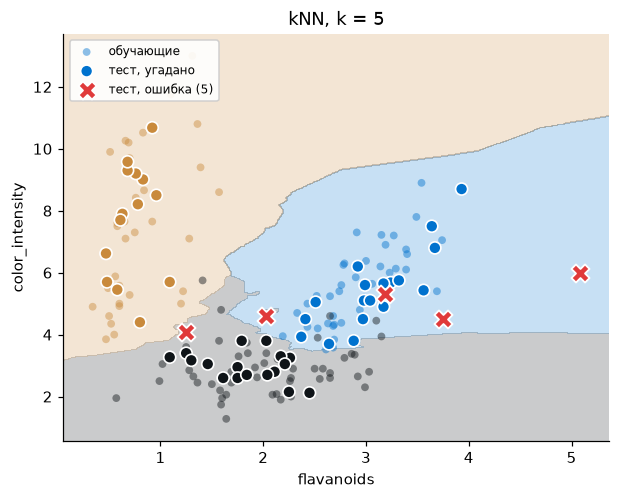

In [17]:
show_decision(KNeighborsClassifier(n_neighbors=5),
              title="kNN, k = 5")
plt.show()

Граница получилась рваной: она огибает отдельные точки и явно подстраивается
под конкретные объекты обучающей выборки. Это свойство метода, к нему
вернемся, когда будем выбирать k.

### Соседей видно

У модели есть метод, который показывает, на кого именно она смотрела,
когда отвечала. Полезно, когда предсказание кажется странным.

In [18]:
distances, indices = knn.kneighbors(X_test[:3])

for i in range(3):
    print(f"объект {i}: истинный сорт {y_test[i]}, модель ответила {y_pred_knn[i]}")
    print(f"  соседи:      сорта {y_train[indices[i]]}")
    print(f"  расстояния:  {np.round(distances[i], 1)}")
    print()

объект 0: истинный сорт 0, модель ответила 0
  соседи:      сорта [0 0 0 0 0]
  расстояния:  [12.3 13.2 36.7 37.2 56.8]

объект 1: истинный сорт 1, модель ответила 1
  соседи:      сорта [1 1 1 1 1]
  расстояния:  [11.4 13.1 18.6 30.  31.3]

объект 2: истинный сорт 0, модель ответила 0
  соседи:      сорта [0 0 0 0 0]
  расстояния:  [165.  200.1 230.  305.1 360.5]



## 6. Ловушка масштаба

Вернемся к тому, что заметили в начале. У `proline` значения около тысячи,
у остальных признаков — единицы и доли.

Посмотрите на формулу расстояния еще раз. Разность по `proline` в тысячу
единиц дает вклад в миллион, разность по `hue` в половину единицы — вклад
в четверть. То есть расстояние определяется одним признаком, а остальные
двенадцать не участвуют вообще.

Лечится это стандартизацией: у каждого признака вычитается среднее
и результат делится на стандартное отклонение.

$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

После такого преобразования у всех признаков среднее ноль и разброс единица,
и в расстояние они входят на равных.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"без масштабирования: {acc_raw:.3f}")
print(f"с масштабированием:  {acc_scaled:.3f}")

без масштабирования: 0.722
с масштабированием:  0.944


In [20]:
# --- проверка ---

# 1. после стандартизации у обучающей части среднее ноль, разброс единица
assert np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-9), "среднее трейна не ноль"
assert np.allclose(X_train_scaled.std(axis=0), 1, atol=1e-9), "разброс трейна не единица"

# 2. у тестовой части среднее НЕ обязано быть нулем: параметры взяты с трейна
assert not np.allclose(X_test_scaled.mean(axis=0), 0, atol=1e-6), \
    "похоже, scaler обучен на тесте, а так делать нельзя"

# 3. форма данных не изменилась
assert X_train_scaled.shape == X_train.shape and X_test_scaled.shape == X_test.shape

# 4. масштабирование улучшило качество, причем заметно
assert acc_scaled > acc_raw, "после масштабирования качество не выросло"
print(f"проверки пройдены, прирост {acc_scaled - acc_raw:+.3f}")

проверки пройдены, прирост +0.222


Разница огромная. Один вызов `StandardScaler` дал больше, чем дал бы любой
подбор гиперпараметров.

Отдельно обратите внимание на две строчки:

```python
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

На обучающей части — `fit_transform`, на тестовой — только `transform`.
Среднее и стандартное отклонение считаются **исключительно по трейну**.
Если посчитать их по всем данным сразу, информация о тесте просочится
в обучение. Это называется утечкой, и это одна из самых частых ошибок
в машинном обучении. Отдельное занятие про это будет четвертым.

Третья проверка в ячейке выше ловит ровно эту ошибку: если бы вы обучили
`scaler` на тесте, среднее теста оказалось бы нулевым и проверка упала бы.

### И снова картинка

Слева было, справа стало. Данные те же самые, изменился только масштаб осей.

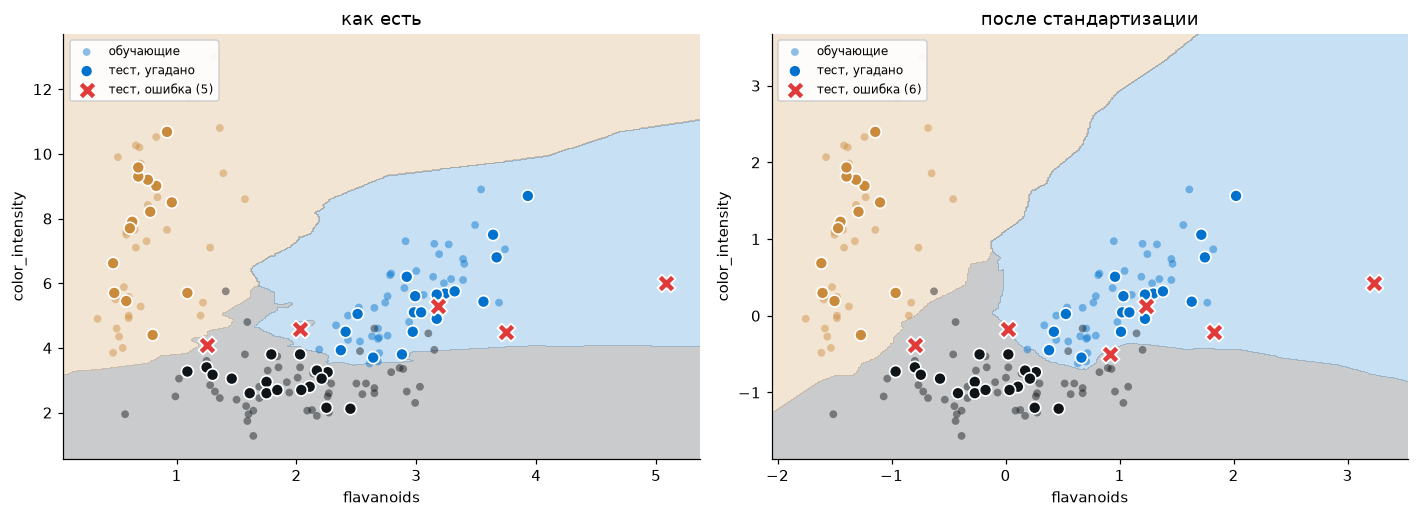

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
show_decision(KNeighborsClassifier(n_neighbors=5), scale=False,
              title="как есть", ax=axes[0])
show_decision(KNeighborsClassifier(n_neighbors=5), scale=True,
              title="после стандартизации", ax=axes[1])
plt.tight_layout()
plt.show()

Обратите внимание не на форму зон, а на то, вдоль какой оси они вытянуты.
Без масштабирования граница идет почти горизонтально: модель почти
не смотрит на признак с меньшим разбросом. После стандартизации оба
признака участвуют на равных, и граница становится косой.

### Насколько сильно масштаб перекосил расстояния

Посмотрим на вклад каждого признака в суммарное расстояние.

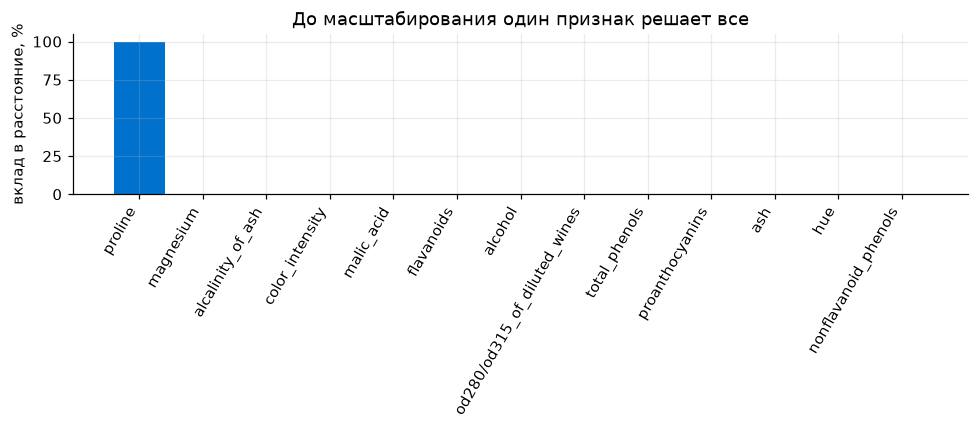

доля proline: 99.73%


In [22]:
variance = X_train.var(axis=0)
share = variance / variance.sum()

order = np.argsort(share)[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(share)), share[order] * 100, color="#0072CE")
ax.set_xticks(range(len(share)))
ax.set_xticklabels([wine.feature_names[i] for i in order], rotation=60, ha="right")
ax.set_ylabel("вклад в расстояние, %")
ax.set_title("До масштабирования один признак решает все")
plt.tight_layout()
plt.show()

print(f"доля proline: {share[order][0] * 100:.2f}%")

## 7. Выбор k

Единственный параметр метода. Что происходит на краях:

- `k = 1` — ответ определяется одним ближайшим объектом. Модель подстраивается
  под каждую точку, включая шум. Это переобучение;
- `k = n` — соседями оказывается вся выборка, и ответ всегда один и тот же,
  самый частый класс. Это наш baseline, то есть недообучение.

Истина где-то посередине, и найти ее можно только экспериментом.

In [23]:
k_values = list(range(1, 41))
train_scores, test_scores = [], []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

best_k = k_values[int(np.argmax(test_scores))]
print(f"лучшее k на тесте: {best_k}, accuracy {max(test_scores):.3f}")

лучшее k на тесте: 21, accuracy 1.000


In [24]:
# --- проверка ---

# 1. по одному значению на каждое k
assert len(train_scores) == len(k_values) == len(test_scores), "не совпала длина списков"

# 2. все значения это доли
assert all(0.0 <= s <= 1.0 for s in train_scores + test_scores), "accuracy вне [0, 1]"

# 3. при k=1 модель отвечает идеально на собственной обучающей выборке
assert np.isclose(train_scores[0], 1.0), "при k=1 train accuracy обязана быть равна 1"

# 4. на тесте при k=1 такого нет: там модель уже ошибается
assert test_scores[0] < 1.0, "на тесте при k=1 не должно быть идеального результата"

# 5. лучшее k выбрано корректно
assert test_scores[k_values.index(best_k)] == max(test_scores), "best_k не соответствует максимуму"

print(f"проверки пройдены: train при k=1 равен {train_scores[0]:.3f}, "
      f"test {test_scores[0]:.3f}")

проверки пройдены: train при k=1 равен 1.000, test 0.963


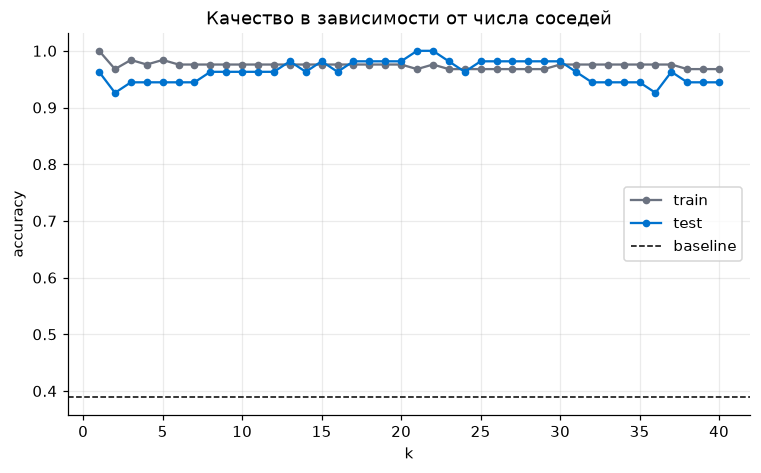

In [25]:
fig, ax = plt.subplots()
ax.plot(k_values, train_scores, "o-", ms=4, label="train", color="#6B7280")
ax.plot(k_values, test_scores, "o-", ms=4, label="test", color="#0072CE")
ax.axhline(baseline_acc, ls="--", color="black", lw=1, label="baseline")
ax.set_xlabel("k")
ax.set_ylabel("accuracy")
ax.set_title("Качество в зависимости от числа соседей")
ax.legend()
plt.show()

На графике видно главное, ради чего он строился: при `k = 1` качество на трейне
равно единице. Модель отвечает идеально на данных, которые видела, потому что
ближайший сосед объекта — он сам. На тесте при этом качество ниже.

Расхождение между двумя кривыми и есть переобучение, увиденное глазами.

**Важная оговорка про честность.** Мы только что выбрали `k` по тестовой
выборке. Строго говоря, так делать нельзя: тест перестает быть независимой
проверкой, если по нему что-то подбирали. Правильный способ — отдельная
валидационная часть или кросс-валидация. Разберем на четвертом занятии,
пока просто зафиксируйте, что здесь мы схитрили.

## 8. Метрики: почему accuracy недостаточно

Возьмем другой датасет — диагностика опухоли молочной железы, два класса.
И построим модель, которая всегда отвечает «доброкачественная».

In [26]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=SEED, stratify=cancer.target
)

print("классы:", dict(zip(range(2), cancer.target_names)))
print("доли в тесте:", np.round(np.bincount(yc_test) / len(yc_test), 3))

lazy = DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train)
print(f"\naccuracy модели, которая всегда говорит одно и то же: "
      f"{accuracy_score(yc_test, lazy.predict(Xc_test)):.3f}")

классы: {0: np.str_('malignant'), 1: np.str_('benign')}
доли в тесте: [0.374 0.626]

accuracy модели, которая всегда говорит одно и то же: 0.626


Шестьдесят три процента правильных ответов у модели, которая не смотрит
на данные вообще. И это еще мягкий случай: при соотношении классов один
к тысяче такая модель наберет 99.9 процента.

Значит accuracy сама по себе ничего не говорит. Нужно смотреть, **какие
именно** ошибки делает модель. Для этого предсказания раскладывают
на четыре клетки.

|  | предсказано 1 | предсказано 0 |
|:--|:--|:--|
| **на самом деле 1** | TP, верно найденные | FN, пропущенные |
| **на самом деле 0** | FP, ложная тревога | TN, верно отвергнутые |

Отсюда растут две метрики:

$$\text{precision} = \frac{TP}{TP + FP}, \qquad
  \text{recall} = \frac{TP}{TP + FN}$$

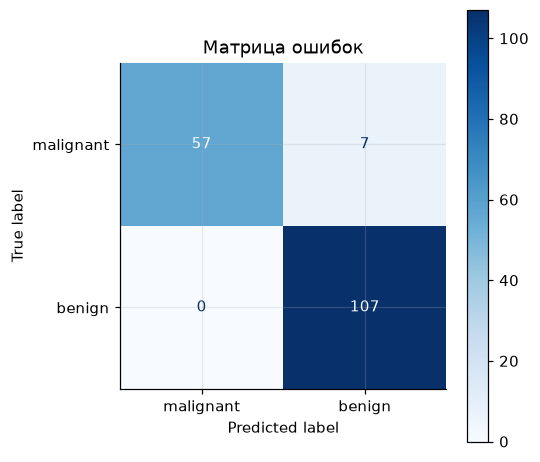

              precision    recall  f1-score   support

   malignant       1.00      0.89      0.94        64
      benign       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)

knn_c = KNeighborsClassifier(n_neighbors=5).fit(Xc_train_s, yc_train)
yc_pred = knn_c.predict(Xc_test_s)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    yc_test, yc_pred, display_labels=cancer.target_names, cmap="Blues", ax=ax
)
ax.set_title("Матрица ошибок")
plt.tight_layout()
plt.show()

print(classification_report(yc_test, yc_pred, target_names=cancer.target_names))

In [28]:
# --- проверка ---
from sklearn.metrics import confusion_matrix, precision_score, recall_score

cm = confusion_matrix(yc_test, yc_pred)

# 1. матрица два на два, потому что классов два
assert cm.shape == (2, 2), f"ожидали матрицу (2, 2), получили {cm.shape}"

# 2. сумма всех клеток равна числу объектов теста
assert cm.sum() == len(yc_test), "в матрицу попали не все объекты"

# 3. диагональ это правильные ответы, и их доля равна accuracy
assert np.isclose(np.trace(cm) / cm.sum(), accuracy_score(yc_test, yc_pred)), \
    "диагональ матрицы не сходится с accuracy"

# 4. считаем precision и recall руками и сверяем с библиотекой
tn, fp, fn, tp = cm.ravel()
assert np.isclose(tp / (tp + fp), precision_score(yc_test, yc_pred)), "precision не сошелся"
assert np.isclose(tp / (tp + fn), recall_score(yc_test, yc_pred)), "recall не сошелся"

print(f"проверки пройдены")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

проверки пройдены
  TP=107  FP=7
  FN=0  TN=57


Матрица ошибок сразу показывает, чего именно модель не умеет.

**Precision**, точность: из тех, кого модель назвала больными, сколько
действительно больны. Отвечает на вопрос «можно ли верить, когда модель
говорит да».

**Recall**, полнота: из всех больных сколько модель нашла. Отвечает на вопрос
«скольких мы пропустили».

Между ними всегда компромисс, и выбор зависит от цены ошибки. В медицинской
диагностике пропущенная опухоль страшнее ложной тревоги, поэтому здесь важнее
recall. В спам-фильтре наоборот: письмо от начальника в папке «спам» хуже,
чем реклама во входящих, поэтому важнее precision.

Метрику выбирает не алгоритм, а тот, кто понимает задачу.

## 9. Наивный Байес

Второй метод сегодняшнего занятия устроен принципиально иначе. kNN ничего
не вычисляет заранее и хранит всю выборку. Наивный Байес наоборот: он
на этапе обучения считает несколько чисел, а выборку выбрасывает.

### Откуда берется формула

В основе теорема Байеса. Она связывает то, что мы хотим знать, с тем,
что можно оценить по данным:

$$P(y = c \mid x) = \frac{P(x \mid y = c) \cdot P(y = c)}{P(x)}$$

Разберем по частям.

- $P(y = c \mid x)$ — **апостериорная** вероятность. Насколько вероятен класс
  $c$, если мы уже увидели объект $x$. Это ровно то, что нужно для ответа.
- $P(y = c)$ — **априорная** вероятность класса. Насколько класс вообще
  часто встречается, еще до того, как мы посмотрели на признаки.
  Оценивается просто долей класса в обучающей выборке.
- $P(x \mid y = c)$ — **правдоподобие**. Насколько типичен такой объект
  для этого класса.
- $P(x)$ — вероятность увидеть такой объект вообще

### Как из вероятностей получается ответ

Здесь стоит остановиться: это место обычно проскакивают, а оно ключевое.

Теорема Байеса считает вероятность **для каждого класса отдельно**.
Сортов три, значит получится три числа: $P(y = 0 \mid x)$,
$P(y = 1 \mid x)$ и $P(y = 2 \mid x)$. Но модель должна выдать **один**
ответ, а не три числа. Нужно правило выбора.

Правило самое естественное: назвать тот класс, чья вероятность больше.
Записывается это через $\arg\max$ — не само значение максимума, а тот
аргумент, на котором максимум достигается, то есть номер класса:

$$a(x) = \arg\max_{c} \; P(y = c \mid x)$$

Вот здесь функция $a(x)$ из второго раздела получает конкретный вид.
Подставим в нее теорему Байеса:

$$a(x) = \arg\max_{c} \; \frac{P(x \mid y = c) \, P(y = c)}{P(x)}$$

Осталась деталь, которая экономит всю работу. У всех трех дробей
знаменатель одинаковый: $P(x)$ от класса не зависит. Деление на одно
и то же положительное число не меняет порядок чисел — кто был больше,
тот больше и остался. Значит для выбора максимума знаменатель можно
выбросить:

$$a(x) = \arg\max_{c} \; P(y = c) \cdot P(x \mid y = c)$$

Это важно, потому что именно $P(x)$ было бы труднее всего оценить: это
распределение самих данных, многомерное и никак нам не заданное. Мы
не научились его считать — мы обошли необходимость его считать.

### В чем наивность

Осталась одна проблема, и она серьезная. Правдоподобие $P(x \mid y = c)$ —
это совместное распределение всех тринадцати признаков сразу. Чтобы оценить
его по выборке честно, данных нужно экспоненциально много: комбинаций
значений больше, чем объектов в любом реальном датасете.

Метод решает эту проблему грубо. Он предполагает, что при известном классе
признаки **независимы**, и тогда совместная вероятность распадается
в произведение одномерных:

$$P(x \mid y = c) = \prod_{j=1}^{d} P(x_j \mid y = c)$$

Здесь важно не запутаться в обозначениях. В левой части $x$ — это весь
объект целиком, вектор из тринадцати чисел, а $y$ — **его же** класс.
В правой части $x_j$ — отдельный признак того же самого объекта, а $y$
остается тем же: класс у объекта один, по признакам он не размножается.
Произведение идет по признакам, а условие $y = c$ во всех множителях
одно и то же.

Вот это предположение и называется наивным. Оно почти всегда неверно:
в вине содержание флавоноидов и общее содержание фенолов очевидно связаны.
Метод все равно работает, и это одна из самых приятных странностей
машинного обучения. Причина в том, что для выбора класса не нужны точные
вероятности, достаточно правильного порядка.

Итоговое решающее правило:

$$a(x) = \arg\max_{c} \; P(y = c) \prod_{j=1}^{d} P(x_j \mid y = c)$$

### Гауссовский вариант: где тут признаки и наблюдения

Осталось сказать, как оценивать одномерные множители. Сначала договоримся
об обозначениях, иначе дальше будет каша.

- $i$ — номер объекта в обучающей выборке, от 1 до $n$
- $j$ — номер признака, от 1 до $d$ (у нас $d = 13$)
- $c$ — номер класса (у нас три сорта)
- $x_{ij}$ — значение $j$-го признака у $i$-го объекта, одно число в таблице
- $y_i$ — класс $i$-го объекта

Теперь предположение метода: **внутри каждого класса каждый признак
распределен нормально**. То есть для класса $c$ и признака $j$ есть своя
пара чисел, среднее и дисперсия:

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}}
  \exp\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

Читается так: подставьте сюда значение признака $j$ у интересующего вас
объекта, и формула вернет, насколько такое значение типично для класса $c$.
Индексы $c$ и $j$ у $\mu$ и $\sigma$ означают, что **своя пара чисел
у каждой комбинации класса и признака**.

### Откуда берутся эти числа

Вот здесь и появляются наблюдения. Каждый параметр считается по тем строкам
обучающей таблицы, у которых нужный класс:

$$\hat{\mu}_{cj} = \frac{1}{n_c}\sum_{i:\, y_i = c} x_{ij}
\qquad
\hat{\sigma}^2_{cj} = \frac{1}{n_c}\sum_{i:\, y_i = c}
  \left(x_{ij} - \hat{\mu}_{cj}\right)^2
\qquad
\hat{P}(y = c) = \frac{n_c}{n}$$

Запись $\sum_{i:\, y_i = c}$ читается «сумма по тем $i$, у которых класс
равен $c$». То есть: **взяли все вина сорта $c$, посмотрели на их $j$-й
признак, усреднили**. И так для каждой пары класс-признак.

На питоне это одна строка: `X_train[y_train == c].mean(axis=0)` дает сразу
все тринадцать средних для класса $c$. Ниже посчитаем руками и сверимся
с библиотекой.

Всего чисел: три класса на тринадцать признаков дают 39 средних и 39
дисперсий, плюс три доли классов. Восемьдесят одно число. Это вся модель,
обучающая выборка после этого не нужна.

### Что на самом деле получилось из этого произведения

Соберем два предположения вместе и посмотрим, во что они складываются.

Первое: признаки внутри класса независимы, поэтому совместная плотность
распадается в произведение. Второе: каждый множитель нормальный. Значит

$$P(x \mid y = c) = \prod_{j=1}^{d}
  \frac{1}{\sqrt{2\pi\sigma_{cj}^2}}
  \exp\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

Перемножим экспоненты: показатели складываются, а множители перед ними
собираются в один. Получается

$$P(x \mid y = c) = \frac{1}{(2\pi)^{d/2}
  \left(\prod_j \sigma_{cj}^2\right)^{1/2}}
  \exp\left(-\frac{1}{2}\sum_{j=1}^{d}
  \frac{(x_j - \mu_{cj})^2}{\sigma_{cj}^2}\right)$$

Это в точности **многомерное нормальное распределение** с вектором средних
$\mu_c = (\mu_{c1}, \dots, \mu_{cd})$ и ковариационной матрицей

$$\Sigma_c = \mathrm{diag}\left(\sigma_{c1}^2, \dots,
  \sigma_{cd}^2\right)$$

То есть произведение одномерных нормальных плотностей по разным координатам
дает многомерную нормальную плотность. Это и есть настоящий смысл модели:
**каждый класс описывается одним нормальным облаком в тринадцатимерном
пространстве**.

Оговорка, чтобы не запомнить неверно: речь о произведении плотностей
по разным координатам. Произведение двух нормальных случайных величин
нормальным не будет, это другое утверждение.

### Где здесь наивность, если посмотреть на матрицу

Вся наивность метода спряталась в одном слове: матрица $\Sigma_c$
**диагональная**. Вне диагонали стоят нули, а там живут ковариации между
признаками. Обнулить их — то же самое, что заявить: внутри класса признаки
не связаны.

Проверить это заявление легко: посчитаем настоящую ковариационную матрицу
одного класса и посмотрим, много ли мы выбросили.

In [29]:
c = 0
rows = X_train[y_train == c]

full = np.cov(rows, rowvar=False)          # честная матрица со всеми связями
diagonal_only = np.diag(np.diag(full))     # то, что оставляет наивный Байес

# корреляции нагляднее ковариаций: они в одном масштабе
corr = np.corrcoef(rows, rowvar=False)
off = corr[~np.eye(len(corr), dtype=bool)]

print(f"размер матрицы: {full.shape}")
print(f"чисел вне диагонали: {off.size}, и все они объявлены нулями")
print()
print(f"самая сильная связь по модулю: {np.abs(off).max():.2f}")
print(f"средняя по модулю:             {np.abs(off).mean():.2f}")
print(f"связей сильнее 0.5:            {(np.abs(off) > 0.5).sum()}")

размер матрицы: (13, 13)
чисел вне диагонали: 156, и все они объявлены нулями

самая сильная связь по модулю: 0.78
средняя по модулю:             0.23
связей сильнее 0.5:            14


In [30]:
# какие именно признаки связаны сильнее всего
pairs = []
for a in range(len(corr)):
    for b in range(a + 1, len(corr)):
        pairs.append((abs(corr[a, b]), corr[a, b], a, b))

for _, value, a, b in sorted(pairs, reverse=True)[:5]:
    print(f"  {value:+.2f}   {wine.feature_names[a]} и {wine.feature_names[b]}")

  +0.78   total_phenols и flavanoids
  +0.73   flavanoids и color_intensity
  +0.64   total_phenols и color_intensity
  +0.60   ash и alcalinity_of_ash
  +0.56   flavanoids и proanthocyanins


### Та же матрица картинкой

Числами связи видно плохо, тепловой картой — сразу. Слева настоящие
корреляции внутри класса, справа то, что от них оставляет наивный Байес.

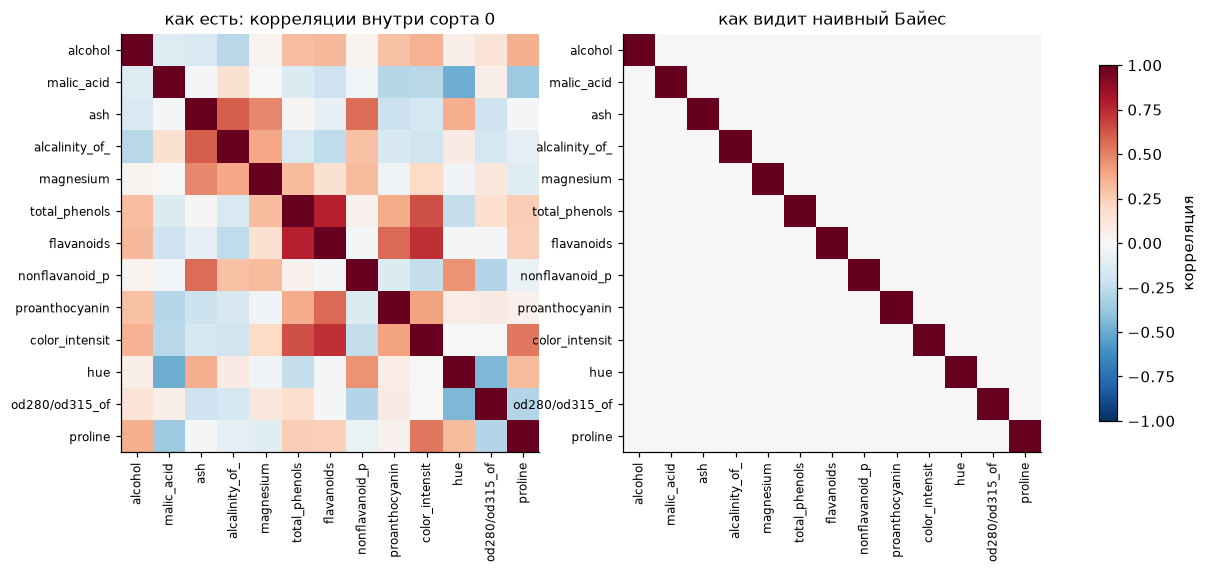

In [31]:
short = [n[:14] for n in wine.feature_names]
naive_view = np.eye(len(corr))          # единицы на диагонали, нули везде еще

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
for ax, matrix, title in [
    (axes[0], corr, f"как есть: корреляции внутри сорта {c}"),
    (axes[1], naive_view, "как видит наивный Байес"),
]:
    picture = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(short)))
    ax.set_yticks(range(len(short)))
    ax.set_xticklabels(short, rotation=90, fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.grid(False)

fig.colorbar(picture, ax=axes, shrink=0.75, label="корреляция")
plt.show()

Красное это положительная связь, синее отрицательная, белое отсутствие
связи. На левой картинке цветных клеток много, и это настоящая структура
данных. Правая картинка — то же самое после предположения о независимости:
красная диагональ и белизна вокруг.

Разница между этими двумя картинками и есть цена наивности. Метод честно
выбрасывает всю информацию о том, как признаки связаны друг с другом.

Связи есть, и довольно сильные: содержание флавоноидов и общее содержание
фенолов измеряют по сути близкие вещи, и это видно в числах. Наивный Байес
все эти связи игнорирует.

И все равно работает. Причина в том, что для выбора класса нужны
не точные вероятности, а правильный **порядок** между классами. Ошибки
от игнорирования корреляций часто сдвигают все три числа в одну сторону
и порядок не меняют.

Если корреляции все же учитывать честно, получится другой метод: там
$\Sigma_c$ берется целиком, вместе с недиагональными элементами.
Он называется квадратичным дискриминантным анализом, и параметров у него
уже не 39 на класс, а больше сотни — значит и данных нужно заметно больше.

In [32]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

print(f"наивный Байес:      {accuracy_score(y_test, nb.predict(X_test)):.3f}")
print(f"kNN с масштабом:    {acc_scaled:.3f}")
print(f"kNN без масштаба:   {acc_raw:.3f}")
print(f"baseline:           {baseline_acc:.3f}")
print()
print("вся выученная модель:")
print("  априорные вероятности классов:", nb.class_prior_.round(3))
print("  таблица средних:              ", nb.theta_.shape)
print("  таблица дисперсий:            ", nb.var_.shape)

наивный Байес:      1.000
kNN с масштабом:    0.944
kNN без масштаба:   0.722
baseline:           0.389

вся выученная модель:
  априорные вероятности классов: [0.331 0.403 0.266]
  таблица средних:               (3, 13)
  таблица дисперсий:             (3, 13)


### Посчитаем параметры руками

Чтобы формулы выше перестали быть абстракцией, посчитаем их сами
и сверим с тем, что выучила библиотека.

In [33]:
# берем один класс и один признак
c = 0
j = wine.feature_names.index("proline")

# строки обучающей таблицы, у которых класс равен c
rows = X_train[y_train == c]
print(f"объектов сорта {c} в обучающей выборке: {len(rows)}")
print(f"их значения признака {wine.feature_names[j]!r} (первые 8):")
print(" ", np.round(rows[:8, j], 1))
print()

mu = rows[:, j].mean()
var = rows[:, j].var()
print(f"среднее по этим объектам:   {mu:.2f}")
print(f"дисперсия по этим объектам: {var:.2f}")
print()
print(f"а что выучил sklearn:       {nb.theta_[c, j]:.2f} и {nb.var_[c, j]:.2f}")

объектов сорта 0 в обучающей выборке: 41
их значения признака 'proline' (первые 8):
  [1320. 1285.  880. 1515. 1045. 1280. 1375. 1150.]

среднее по этим объектам:   1112.80
дисперсия по этим объектам: 39725.67

а что выучил sklearn:       1112.80 и 39725.67


In [34]:
# то же самое сразу для всех классов и всех признаков, тремя строками
means = np.array([X_train[y_train == c].mean(axis=0) for c in range(3)])
variances = np.array([X_train[y_train == c].var(axis=0) for c in range(3)])
priors = np.array([(y_train == c).mean() for c in range(3)])

print("таблица средних:   ", means.shape, "  класс на признак")
print("таблица дисперсий: ", variances.shape)
print("доли классов:      ", np.round(priors, 3))
print()
print("совпадает со sklearn:", np.allclose(means, nb.theta_))

таблица средних:    (3, 13)   класс на признак
таблица дисперсий:  (3, 13)
доли классов:       [0.331 0.403 0.266]

совпадает со sklearn: True


Вот и вся модель: две таблицы три на тринадцать и три доли. Никаких
обучающих объектов внутри не хранится — в отличие от kNN, который держит
всю выборку целиком.

Три вещи, которые стоит обсудить.

Первая: наивный Байес обыграл kNN. Метод, который считает несколько средних
и дисперсий, оказался лучше метода, который хранит всю выборку. Более сложное
не значит более точное.

Вторая: kNN без масштабирования проиграл всем. Мы это уже разобрали.

Третья, и она важнее двух первых. Наивный Байес не ошибся **ни разу**.
Правильная реакция на такое число — не радость, а вопрос «почему».
Разберемся, потому что это важнее самого числа.

### Откуда взялась единица

Первое подозрение всегда одно: не протекли ли данные, не обучились ли мы
случайно на тесте. Здесь нет: `fit` видел только `X_train`, а `X_test`
попал лишь в `predict`.

Второе объяснение проще. В тестовой выборке пятьдесят четыре объекта,
значит одна ошибка стоит 0.019. Разница между 1.000 и 0.981 — это ровно
один объект, то есть шум конкретного разбиения, а не свойство модели.

Проверим это прямо, а не на словах: перетасуем данные две сотни раз
и посмотрим на разброс.

In [35]:
scores = []
for seed in range(200):
    tr_x, te_x, tr_y, te_y = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    scores.append(GaussianNB().fit(tr_x, tr_y).score(te_x, te_y))
scores = np.array(scores)

print(f"среднее по 200 разбиениям: {scores.mean():.3f}")
print(f"худшее:                    {scores.min():.3f}")
print(f"лучшее:                    {scores.max():.3f}")
print(f"доля разбиений с ровно 1.000: {(scores == 1.0).mean():.0%}")
print()
print(f"наше разбиение (random_state=42): {scores[42]:.3f}")

среднее по 200 разбиениям: 0.975
худшее:                    0.926
лучшее:                    1.000
доля разбиений с ровно 1.000: 19%

наше разбиение (random_state=42): 1.000


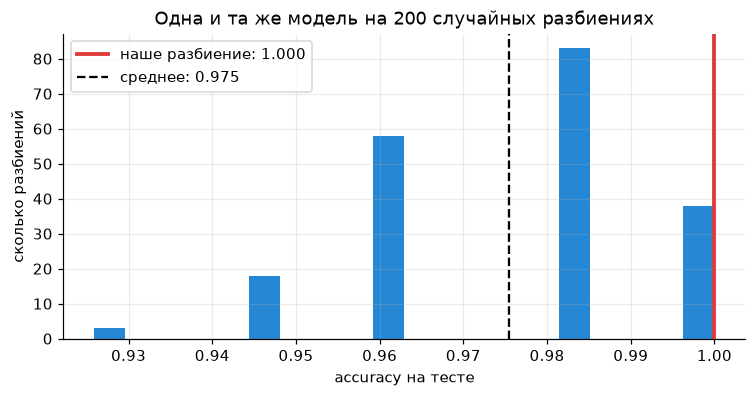

In [36]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(scores, bins=20, color="#0072CE", alpha=0.85)
ax.axvline(scores[42], color="#E03A3A", lw=2.5,
           label=f"наше разбиение: {scores[42]:.3f}")
ax.axvline(scores.mean(), color="black", ls="--", lw=1.5,
           label=f"среднее: {scores.mean():.3f}")
ax.set_xlabel("accuracy на тесте")
ax.set_ylabel("сколько разбиений")
ax.set_title("Одна и та же модель на 200 случайных разбиениях")
ax.legend()
plt.show()

Картина понятная. Единица выпадает примерно в каждом пятом разбиении,
а типичный результат около 0.97. Нам просто досталось удачное деление.

Значит модель хорошая, но не идеальная, и число 1.000 не говорит
о ней ничего сверх того, что говорит 0.97.

Отсюда практический вывод, который пригодится в домашних работах.
**Одно число на одном разбиении — это не результат измерения.** Правильный
способ — усреднить по нескольким разбиениям, и называется он кросс-валидацией.

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = cross_val_score(GaussianNB(), X, y, cv=cv)

print("качество по пяти частям:", np.round(folds, 3))
print(f"итог: {folds.mean():.3f} плюс-минус {folds.std():.3f}")

качество по пяти частям: [0.944 1.    0.972 0.943 1.   ]
итог: 0.972 плюс-минус 0.025


Вот это уже честная оценка качества: около 0.97, и мы знаем, насколько
она гуляет. Кросс-валидацию разберем подробно на четвертом занятии,
а пока запомните сам прием.

И общее правило. Когда метрика подозрительно хороша, первым делом ищут
не повод для гордости, а объяснение: утечку данных, слишком маленький
тест или везение с разбиением. Здесь оказалось последнее.

Наивный Байес работает без масштабирования, и это не случайность. Он не
считает расстояний: для каждого признака отдельно оценивается свое
распределение внутри каждого класса. Единицы измерения при этом не важны.

Посмотрим, что именно он выучил.

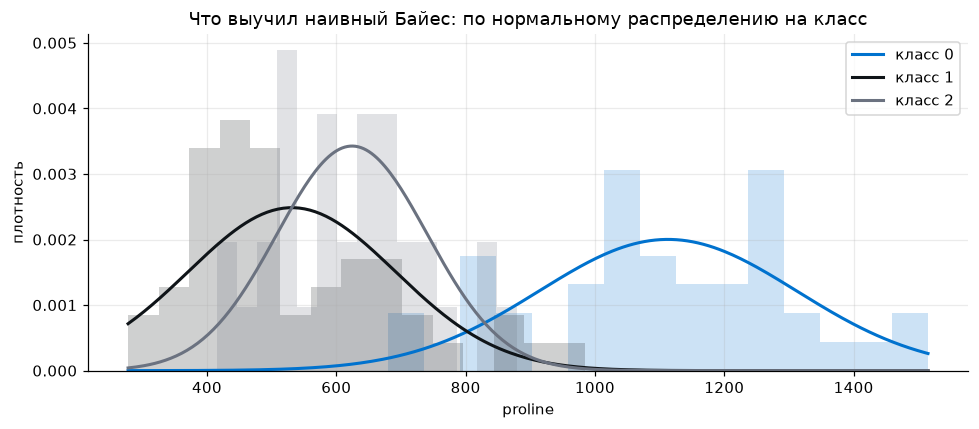

In [38]:
feature_idx = wine.feature_names.index("proline")

fig, ax = plt.subplots(figsize=(9, 4))
grid = np.linspace(X_train[:, feature_idx].min(), X_train[:, feature_idx].max(), 300)
colors = ["#0072CE", "#0F1418", "#6B7280"]

for c in range(3):
    mean = nb.theta_[c, feature_idx]
    std = np.sqrt(nb.var_[c, feature_idx])
    density = np.exp(-0.5 * ((grid - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))
    ax.plot(grid, density, color=colors[c], lw=2, label=f"класс {c}")
    ax.hist(X_train[y_train == c, feature_idx], bins=15, density=True,
            alpha=0.2, color=colors[c])

ax.set_xlabel("proline")
ax.set_ylabel("плотность")
ax.set_title("Что выучил наивный Байес: по нормальному распределению на класс")
ax.legend()
plt.tight_layout()
plt.show()

Гистограммы это реальные данные, кривые это то, чем метод их заменил.
Видно, что приближение грубое, и видно, что для разделения классов
его достаточно.

### Две границы рядом

Тот же приeм, что и с kNN: смотрим, как метод делит плоскость.

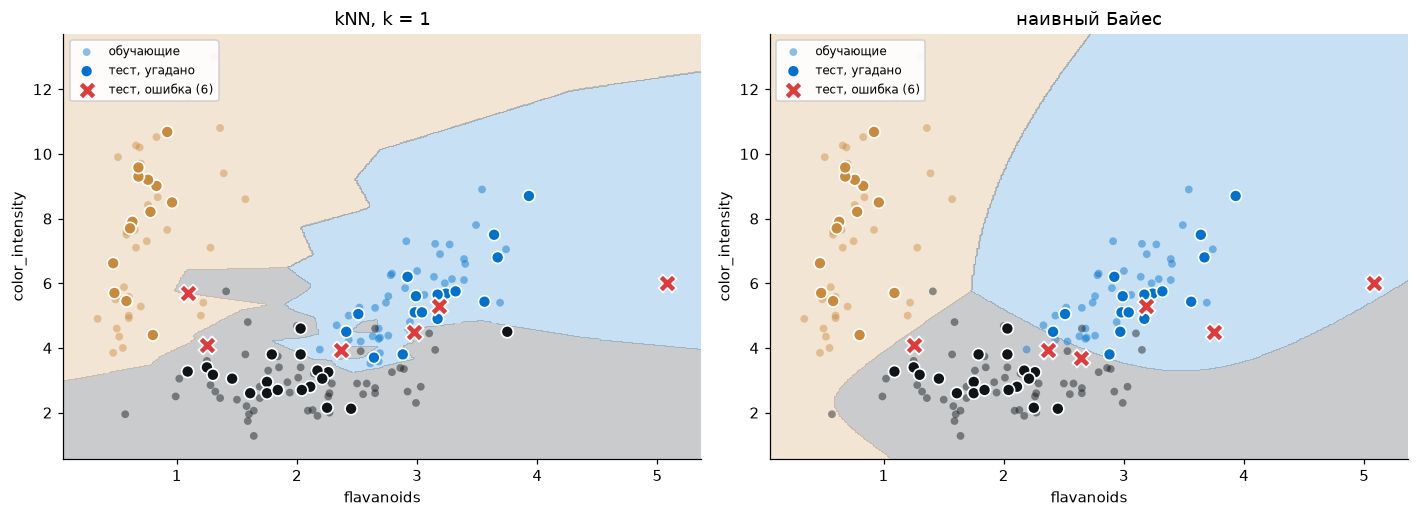

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
show_decision(KNeighborsClassifier(n_neighbors=1), title="kNN, k = 1", ax=axes[0])
show_decision(GaussianNB(), title="наивный Байес", ax=axes[1])
plt.tight_layout()
plt.show()

Слева граница рваная: kNN с одним соседом запомнил каждую точку и обвел
ее собственной зоной. Справа гладкая: наивный Байес не помнит объектов,
он помнит по паре чисел на признак, и большего эти числа нарисовать
не могут.

Какая лучше — зависит от данных. Если признаки внутри класса и правда
похожи на нормальные, гладкая граница выигрывает и требует меньше данных.
Если распределение сложное, она не сможет его повторить, и выиграет kNN.

### Наивный Байес на тексте

Классическое применение метода — фильтрация спама. Здесь признаки другие:
не числа, а количества слов. Поэтому и распределение берут другое,
мультиномиальное:

$$P(w \mid c) = \frac{N_{wc} + \alpha}{N_c + \alpha \, |V|}$$

где $N_{wc}$ — сколько раз слово $w$ встретилось в текстах класса $c$,
$N_c$ — общее число слов в классе, $|V|$ — размер словаря.

Слагаемое $\alpha$ здесь не украшение. Без него слово, ни разу не встреченное
в спаме, дает $P(w \mid \text{спам}) = 0$, а ноль в произведении обнуляет
все выражение целиком: одно незнакомое слово перечеркивает все остальные.
Такое сглаживание называют аддитивным, или сглаживанием Лапласа при $\alpha = 1$.

Предположение о независимости здесь означает «слова в сообщении появляются
независимо друг от друга». Это очевидно неправда, и это все равно работает.

In [40]:
spam = [
    "выиграйте приз прямо сейчас",
    "бесплатный кредит без проверок",
    "срочно подтвердите карту иначе блокировка",
    "заработок от пятидесяти тысяч в день",
    "вы выиграли миллион перейдите по ссылке",
    "только сегодня скидка девяносто процентов",
    "кредит без справок и поручителей срочно",
    "получите бесплатный приз перейдите по ссылке",
]
ham = [
    "во сколько завтра встречаемся",
    "отправил тебе отчет посмотри пожалуйста",
    "не забудь про семинар в субботу",
    "давай перенесем созвон на час позже",
    "спасибо за помощь с задачей",
    "я задержусь минут на пятнадцать",
    "посмотри пожалуйста мой код там ошибка",
    "встреча перенесена на завтра утром",
]

texts = spam + ham
labels = np.array([1] * len(spam) + [0] * len(ham))
print(f"{len(texts)} сообщений, из них спама {labels.sum()}")

16 сообщений, из них спама 8


In [41]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(texts)

print("размер матрицы:", X_text.shape)
print("слов в словаре:", len(vectorizer.vocabulary_))

размер матрицы: (16, 66)
слов в словаре: 66


In [42]:
# --- проверка ---

# 1. строк столько же, сколько сообщений
assert X_text.shape[0] == len(texts), "число строк не равно числу сообщений"

# 2. колонок столько же, сколько слов в словаре
assert X_text.shape[1] == len(vectorizer.vocabulary_), "число колонок не равно размеру словаря"

# 3. в матрице только неотрицательные целые: это счетчики
assert (X_text.toarray() >= 0).all(), "в матрице счетчиков появилось отрицательное число"

# 4. счетчиков не больше, чем слов в сообщениях
words_in_texts = sum(len(t.split()) for t in texts)
assert X_text.sum() <= words_in_texts, "счетчиков больше, чем слов в корпусе"

print("проверки пройдены")
print(f"слов в сообщениях: {words_in_texts}, попало в матрицу: {int(X_text.sum())}")

проверки пройдены
слов в сообщениях: 84, попало в матрицу: 79


### Во что превратились тексты

Посмотрим на результат руками, иначе непонятно, с чем дальше работает модель.

In [43]:
words = vectorizer.get_feature_names_out()
dense = pd.DataFrame(X_text.toarray(), columns=words)

print("первые 12 слов словаря:", list(words[:12]))
print()
for i in (0, 8):
    row = dense.iloc[i]
    kept = {word: int(count) for word, count in row[row > 0].items()}
    print("сообщение:          ", texts[i])
    print("что от него осталось:", kept)
    print()

первые 12 слов словаря: ['без', 'бесплатный', 'блокировка', 'во', 'встреча', 'встречаемся', 'вы', 'выиграйте', 'выиграли', 'давай', 'девяносто', 'день']

сообщение:           выиграйте приз прямо сейчас
что от него осталось: {'выиграйте': 1, 'приз': 1, 'прямо': 1, 'сейчас': 1}

сообщение:           во сколько завтра встречаемся
что от него осталось: {'во': 1, 'встречаемся': 1, 'завтра': 1, 'сколько': 1}



In [44]:
# кусок таблицы целиком: четыре сообщения и слова, которые в них есть
sample = dense.iloc[[0, 1, 8, 9]]
sample = sample.loc[:, sample.sum() > 0]
sample.index = ["спам 1", "спам 2", "обычное 1", "обычное 2"]
sample

,без,бесплатный,во,встречаемся,выиграйте,завтра,кредит,отправил,отчет,пожалуйста,посмотри,приз,проверок,прямо,сейчас,сколько,тебе
спам 1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0
спам 2,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
обычное 1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0
обычное 2,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,1


In [45]:
# часть слов в матрицу не попала, посмотрим какие
lost = sorted({w for t in texts for w in t.split() if w not in vectorizer.vocabulary_})
print("выпали из словаря:", lost)
print("шаблон токена по умолчанию:", vectorizer.token_pattern)

выпали из словаря: ['в', 'и', 'с', 'я']
шаблон токена по умолчанию: (?u)\b\w\w+\b


Все выпавшие слова однобуквенные. Причина в шаблоне токена по умолчанию:
`\b\w\w+\b` требует минимум две буквы подряд, поэтому предлоги и союзы
из одной буквы просто не считаются словами.

Хорошо это или плохо, зависит от задачи. Для спам-фильтра предлоги
бесполезны, и выбросить их разумно. Но знать про такое поведение нужно:
токенизация по умолчанию уже принимает решения за вас, а вы об этом
можете не догадываться. Шаблон меняется параметром `token_pattern`.

In [46]:
# матрица почти пустая, и это норма для текстов
total = X_text.shape[0] * X_text.shape[1]
filled = X_text.nnz
print(f"клеток всего:    {total}")
print(f"из них ненулевых: {filled}  ({filled / total:.1%})")
print()
print("поэтому CountVectorizer возвращает не обычный массив, а разреженный:")
print(" ", type(X_text).__name__)

клеток всего:    1056
из них ненулевых: 79  (7.5%)

поэтому CountVectorizer возвращает не обычный массив, а разреженный:
  csr_matrix


Каждое сообщение стало строкой из нулей и единиц, порядок слов потерян
полностью: «кредит без проверок» и «проверок без кредит» дадут одну и ту же
строку. Такое представление называется мешком слов.

Заполнено меньше десятой части клеток. На настоящих корпусах, где словарь
идет на десятки тысяч слов, доля еще меньше, поэтому такие матрицы хранят
в разреженном виде: только ненулевые значения и их координаты.

### Теперь классификатор

Матрица счетчиков это обычная таблица признаков, и дальше все как всегда:
создать, обучить, предсказать.

In [47]:
from sklearn.naive_bayes import MultinomialNB

nb_text = MultinomialNB()
nb_text.fit(X_text, labels)

probe = [
    "срочно получите бесплатный приз",
    "давай перенесем встречу на завтра",
    "подтвердите карту иначе блокировка",
]

probe_proba = nb_text.predict_proba(vectorizer.transform(probe))[:, 1]

for message, p in zip(probe, probe_proba):
    print(f"  P(спам) = {p:.3f}   {message}")

  P(спам) = 0.981   срочно получите бесплатный приз
  P(спам) = 0.020   давай перенесем встречу на завтра
  P(спам) = 0.939   подтвердите карту иначе блокировка


In [ ]:
# --- проверка ---

# 1. вероятности это вероятности
assert ((probe_proba >= 0) & (probe_proba <= 1)).all(), "вероятность вне отрезка [0, 1]"

# 2. по вероятности на каждое проверяемое сообщение
assert len(probe_proba) == len(probe), "не совпало число вероятностей"

# 3. содержательная проверка: первое и третье спамные, второе нет
assert probe_proba[0] > 0.5, "явный спам не распознан"
assert probe_proba[1] < 0.5, "обычное сообщение принято за спам"
assert probe_proba[2] > 0.5, "явный спам не распознан"

# 4. словарь при этом не изменился: probe размечался старым
assert nb_text.n_features_in_ == X_text.shape[1], (
    "число признаков разошлось; похоже, для probe вызвали fit_transform "
    "вместо transform и завели новый словарь"
)

print("проверки пройдены, вероятности спама:", probe_proba.round(3))

`CountVectorizer` превращает тексты в таблицу: строка это сообщение, колонка
это слово из словаря, в клетке количество вхождений. Такое представление
называется мешком слов, потому что порядок слов теряется полностью.

Посмотрим, какие слова метод считает самыми спамными. Для этого сравним
логарифмы вероятностей слова в двух классах: чем больше разность,
тем сильнее слово тянет в сторону спама.

In [ ]:
log_ratio = nb_text.feature_log_prob_[1] - nb_text.feature_log_prob_[0]
words = np.array(vectorizer.get_feature_names_out())
order = np.argsort(log_ratio)

print("самые спамные слова:")
for w in words[order[-8:]][::-1]:
    print("   ", w)
print()
print("самые нормальные слова:")
for w in words[order[:8]]:
    print("   ", w)

## 10. Что запомнить

**Про библиотеку.** Любая модель в scikit-learn создается с гиперпараметрами,
учится методом `fit` и применяется методом `predict`. `fit` вызывается
только на обучающей выборке — это главное правило, из которого растет
половина ошибок в машинном обучении. Все, что модель выучила, лежит
в атрибутах с подчеркиванием на конце.

**Про kNN.** Обучения нет, вся работа при предсказании. Модель хранит
выборку целиком. Чувствителен к масштабу признаков до полной потери
качества. Единственный гиперпараметр `k` управляет тем, насколько модель
подстраивается под данные.

**Про наивный Байес.** Считает несколько чисел и выбрасывает выборку.
Не зависит от масштаба. Предположение о независимости признаков почти всегда
неверно, а метод все равно работает.

**Про метрики.** Accuracy сама по себе не значит ничего, пока не известно
распределение классов. Матрица ошибок показывает, какие именно ошибки
делает модель. Precision и recall отвечают на разные вопросы, и выбор между
ними определяется ценой ошибки в конкретной задаче.

**Главное.** Baseline считается первым. Модель, которая не обыгрывает
константный ответ, не имеет права на существование.

## Домашнее задание к следующему занятию

1. Посмотреть лекции 2 и 3 из «Тренировок по ML», ссылки в `docs/lectures.md`
2. Завести аккаунт на Hugging Face, он понадобится со второго занятия
3. Доделать лабораторную, если не успели на паре